In [1]:
# Import the necessary packages
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms,models
from torch.utils.data import DataLoader
import torch.nn.functional as F
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
class ResNet50_MLP(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        # Load pretrained ResNet-50
        backbone = models.resnet50(pretrained=True)
        # Remove the original classifier (fc)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])  # output: (batch, 2048, 1, 1)
        for param in self.feature_extractor.parameters():
            param.requires_grad = False  # freeze ResNet backbone

        # Define 2-layer MLP classifier
        self.fc1 = nn.Linear(2048, 224)
        self.fc2 = nn.Linear(224, num_classes)

    def forward(self, x):
        with torch.no_grad():  # no grad for feature extractor
            features = self.feature_extractor(x)
            features = torch.flatten(features, 1)

        self.hidden = F.relu(self.fc1(features))
        out = self.fc2(self.hidden)
        return out

In [3]:
model_caltech42 = ResNet50_MLP().to('cuda')
model_caltech113 = ResNet50_MLP().to('cuda')
model_labelme42 = ResNet50_MLP().to('cuda')
model_labelme113 = ResNet50_MLP().to('cuda')
model_sun42 = ResNet50_MLP().to('cuda')
model_sun113 = ResNet50_MLP().to('cuda')
model_voc42 = ResNet50_MLP().to('cuda')
model_voc113 = ResNet50_MLP().to('cuda')

/home/aban/miniconda3/envs/circuit/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/aban/miniconda3/envs/circuit/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
model_caltech42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_caltech101_resnet42.pth"))
model_caltech113.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_caltech101_resnet113.pth"))
model_labelme42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_labelme_resnet42.pth"))
model_labelme113.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_labelme_resnet113.pth"))
model_sun42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_sun09_resnet42.pth"))
model_sun113.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_sun09_resnet113.pth"))
model_voc42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_voc2007_resnet42.pth"))
model_voc113.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_voc2007_resnet113.pth"))


/tmp/ipykernel_1282049/2922461130.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_caltech42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_caltech101_r

<All keys matched successfully>

In [5]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
vlcs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
caltech = datasets.ImageFolder(root="/home/aban/circuit_tracing/VLCS/Caltech101", transform=vlcs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(caltech))
test_size = len(caltech) - train_size

caltech_train_dataset, caltech_test_dataset = random_split(caltech, [train_size, test_size], generator=generator)

print(f"Train size: {len(caltech_train_dataset)}")
print(f"Test size: {len(caltech_test_dataset)}")

#Load the artpainting dataset
caltech_train_loader = DataLoader(caltech_train_dataset, batch_size=512, shuffle=True, generator=generator)
caltech_test_loader = DataLoader(caltech_test_dataset, batch_size=512, shuffle=False)

Train size: 1132
Test size: 283


In [7]:
# load the dataset from one root directory with subfolders 0-9
labelme = datasets.ImageFolder(root="/home/aban/circuit_tracing/VLCS/LabelMe", transform=vlcs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(labelme))
test_size = len(labelme) - train_size

labelme_train_dataset, labelme_test_dataset = random_split(labelme, [train_size, test_size], generator=generator)

print(f"Train size: {len(labelme_train_dataset)}")
print(f"Test size: {len(labelme_test_dataset)}")

#Load the artpainting dataset
labelme_train_loader = DataLoader(labelme_train_dataset, batch_size=512, shuffle=True, generator=generator)
labelme_test_loader = DataLoader(labelme_test_dataset, batch_size=512, shuffle=False)

Train size: 2124
Test size: 532


In [8]:
# load the dataset from one root directory with subfolders 0-9
sun = datasets.ImageFolder(root="/home/aban/circuit_tracing/VLCS/SUN09", transform=vlcs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(sun))
test_size = len(sun) - train_size

sun_train_dataset, sun_test_dataset = random_split(sun, [train_size, test_size], generator=generator)

print(f"Train size: {len(sun_train_dataset)}")
print(f"Test size: {len(sun_test_dataset)}")

#Load the artpainting dataset
sun_train_loader = DataLoader(sun_train_dataset, batch_size=512, shuffle=True, generator=generator)
sun_test_loader = DataLoader(sun_test_dataset, batch_size=512, shuffle=False)

Train size: 2625
Test size: 657


In [9]:
# load the dataset from one root directory with subfolders 0-9
voc = datasets.ImageFolder(root="/home/aban/circuit_tracing/VLCS/VOC2007", transform=vlcs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(voc))
test_size = len(voc) - train_size

voc_train_dataset, voc_test_dataset = random_split(voc, [train_size, test_size], generator=generator)

print(f"Train size: {len(voc_train_dataset)}")
print(f"Test size: {len(voc_test_dataset)}")

#Load the artpainting dataset
voc_train_loader = DataLoader(voc_train_dataset, batch_size=512, shuffle=True, generator=generator)
voc_test_loader = DataLoader(voc_test_dataset, batch_size=512, shuffle=False)

Train size: 2700
Test size: 676


In [10]:
@torch.no_grad()
def compute_mean_hidden_by_class(model: nn.Module, dataloader, device='cuda'):
    """
    One pass to collect mean ReLU hidden activations per class.
    Requires model.forward to set `model.hidden` (as in your code).
    """
    model.eval().to(device)
    C = model.fc2.out_features
    H = model.fc1.out_features

    sum_hidden = torch.zeros(C, H, device=device)
    count = torch.zeros(C, dtype=torch.long, device=device)

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        _ = model(x)
        a = model.hidden  # (B, H)
        for c in range(C):
            m = (y == c)
            if m.any():
                sum_hidden[c] += a[m].sum(0)
                count[c] += int(m.sum())

    mean_hidden = torch.zeros_like(sum_hidden)
    for c in range(C):
        if count[c] > 0:
            mean_hidden[c] = sum_hidden[c] / count[c].clamp(min=1)

    return mean_hidden, count

In [11]:
@torch.no_grad()
def build_class_circuit_record(model: nn.Module,
                               mean_hidden: torch.Tensor,
                               class_id: int,
                               top_hidden: int = 20,
                               top_inputs_per_hidden: int = 50,
                               positive_only: bool = True,
                               device='cuda'):
    """
    Build a serializable circuit *record* for one class in the requested format.

    Returns a dict:
    {
      'class': int,
      'hidden_nodes': {
          h: {
              'w_in_vec':            [float]*D,               # W1[h, :]
              'edge_weights_in':     {input_idx: float, ...}, # selected subset
              'w_out_vec':           [float]*C,               # W2[:, h]
              'edge_weight_to_class': float                   # W2[c, h]
          }, ...
      },
      'output_node': {
          'w_in_vec_from_hidden': [float]*H                  # W2[c, :]
      },
      'meta': {...}
    }
    """
    model = model.to(device).eval()

    W1 = model.fc1.weight.detach().to(device)  # (H, D)
    b1 = model.fc1.bias.detach().to(device)    # (H,)
    W2 = model.fc2.weight.detach().to(device)  # (C, H)
    b2 = model.fc2.bias.detach().to(device)    # (C,)

    C, H = W2.size(0), W2.size(1)
    D = W1.size(1)

    contrib = W2[class_id] * mean_hidden[class_id]  # (H,)
    if positive_only:
        contrib = torch.clamp(contrib, min=0)

    keepH = min(top_hidden, H)
    top_vals, top_idx = torch.topk(contrib, k=keepH, largest=True, sorted=True)
    hidden_nodes = {}

    for h in top_idx.tolist():
        # pick top-K incoming inputs by |W1[h,i]|
        w_in_abs = W1[h].abs()  # (D,)
        keepK = min(top_inputs_per_hidden, D)
        k_vals, k_idx = torch.topk(w_in_abs, k=keepK, largest=True, sorted=True)
        edge_in = {int(i): float(W1[h, i].item()) for i in k_idx.tolist()}

        hidden_nodes[h] = {
            'w_in_vec': [float(v) for v in W1[h].detach().cpu().numpy()],     # full input->hidden vector
            'edge_weights_in': edge_in,                                       # kept edges only
            'w_out_vec': [float(v) for v in W2[:, h].detach().cpu().numpy()], # hidden->all outputs
            'edge_weight_to_class': float(W2[class_id, h].item())             # hidden->this class
        }

    record = {
        'class': int(class_id),
        'hidden_nodes': hidden_nodes,
        'output_node': {
            'w_in_vec_from_hidden': [float(v) for v in W2[class_id].detach().cpu().numpy()]  # row: hidden->class
        },
        'meta': {
            'input_shape': (3, 28, 28),
            'flat_input_dim': int(D),
            'hidden_dim': int(H),
            'num_classes': int(C),
            'top_hidden': int(keepH),
            'top_inputs_per_hidden': int(top_inputs_per_hidden),
            'positive_only': bool(positive_only)
        }
    }
    return record

In [12]:
@torch.no_grad()
def build_all_class_circuits(model: nn.Module,
                             dataloader,
                             top_hidden: int = 20,
                             top_inputs_per_hidden: int = 50,
                             positive_only: bool = True,
                             device='cuda'):
    """
    Returns:
      circuits = { class_id: <circuit_record> , ... } for all classes present.
    """
    mean_hidden, _ = compute_mean_hidden_by_class(model, dataloader, device=device)
    circuits = {}
    C = model.fc2.out_features
    for c in range(C):
        circuits[c] = build_class_circuit_record(
            model, mean_hidden, class_id=c,
            top_hidden=top_hidden,
            top_inputs_per_hidden=top_inputs_per_hidden,
            positive_only=positive_only,
            device=device
        )
    return circuits


In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
circuits_caltech42 = build_all_class_circuits(model_caltech42, caltech_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_caltech113 = build_all_class_circuits(model_caltech113, caltech_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_labelme42 = build_all_class_circuits(model_labelme42, labelme_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_labelme113 = build_all_class_circuits(model_labelme113, labelme_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_sun42 = build_all_class_circuits(model_sun42, sun_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_sun113 = build_all_class_circuits(model_sun113, sun_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_voc42 = build_all_class_circuits(model_voc42, voc_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)
circuits_voc113 = build_all_class_circuits(model_voc113, voc_train_loader,
                                    top_hidden=5,
                                    top_inputs_per_hidden=10,
                                    positive_only=True,
                                    device=device)

In [14]:
def _l2norm(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    n = np.linalg.norm(x)
    return x / (n + eps)

In [15]:
def vectorize_class_circuit(circ, use_abs_edges=True, include_bias=False):
    """
    Build a single vector for class `c` containing exactly:
      1) weights of the input nodes (aggregate of kept input->hidden edges, weighted by downstream),
      2) weight of the edge connecting input to the output nodes (hidden->class vector),
      3) weight of the output node (class node's incoming vector from all hidden units).

    Returns: v_c (numpy array)
    """
    meta = circ['meta']
    D = meta['flat_input_dim']     # 3*28*28
    H = meta['hidden_dim']
    c = circ['class']

    # --- (1) Input-node weights: aggregate only KEPT input->hidden edges, weighted by downstream |W2[c,h]|
    input_vec = np.zeros(D, dtype=np.float64)
    for h, rec in circ['hidden_nodes'].items():
        whc = float(rec['edge_weight_to_class'])
        wdown = abs(whc) if use_abs_edges else whc
        for i, w_in in rec['edge_weights_in'].items():
            # add contribution of input i through hidden h to class c
            input_vec[int(i)] += wdown * float(w_in)

    # --- (2) Edge vector: hidden->class weights placed in a length-H vector
    edge_vec = np.zeros(H, dtype=np.float64)
    for h, rec in circ['hidden_nodes'].items():
        w = float(rec['edge_weight_to_class'])
        edge_vec[int(h)] = abs(w) if use_abs_edges else w

    # --- (3) Output node weights: the class node's incoming vector from ALL hidden units (row W2[c,:])
    out_vec = np.asarray(circ['output_node']['w_in_vec_from_hidden'], dtype=np.float64)
    if use_abs_edges:
        out_vec = np.abs(out_vec)

    # Optional: include class bias as an extra scalar
    if include_bias and 'bias' in circ['output_node']:
        out_bias = float(circ['output_node']['bias'])
        out_bias = abs(out_bias) if use_abs_edges else out_bias
        out_vec = np.concatenate([out_vec, [out_bias]], axis=0)

    # Normalize each block before concatenation to balance scales
    v = np.concatenate([_l2norm(input_vec), _l2norm(edge_vec), _l2norm(out_vec)], axis=0)
    return v


In [16]:
def build_class_vectors(circuits, **kwargs):
    """
    circuits: {class_id -> circuit_record}
    returns: {class_id -> vector}
    """
    return {c: vectorize_class_circuit(circ, **kwargs) for c, circ in circuits.items()}

In [17]:
def _cos01(u, v, eps=1e-12):
    u = np.asarray(u, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    nu = np.linalg.norm(u); nv = np.linalg.norm(v)
    if nu < eps or nv < eps:
        return 0.0
    cos = float(np.dot(u, v) / (nu * nv))
    return 0.5 * (cos + 1.0)  # map [-1,1] -> [0,1]

In [18]:
def similarity_matrix_from_vectors(vA, vB):
    """
    vA/vB: {class_id -> vector}
    Returns:
      S[i,j] = cosine01( vA[class_i], vB[class_j] ), classes = sorted keys
    """
    classes = sorted(set(vA.keys()) | set(vB.keys()))
    n = len(classes)
    S = np.zeros((n, n), dtype=np.float64)
    for i, ca in enumerate(classes):
        for j, cb in enumerate(classes):
            S[i, j] = _cos01(vA[ca], vB[cb])
    return S, classes

In [19]:
def plot_similarity_matrix_with_values(
    S, classes=None, title="Circuit Similarity (A vs B)",
    figsize=(6,5), cmap='viridis', fmt=".2f", text_size=8
):
    """
    S: (10,10) numpy array with values in [0,1]
    Shows a heatmap and writes each value in the cell.
    """
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.57, vmax=0.73, cmap=cmap, origin='upper')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B")
    ax.set_ylabel("Classes in A")
    ax.set_title(title)

    # Annotate values
    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    # Optional: faint grid for readability
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    plt.tight_layout()
    plt.show()

In [20]:
from graphkitlearn.gklearn.kernels.randomWalkKernel import randomwalkkernel
def circuit_to_graph(circ, use_abs_edges=True, directed=True):
    """
    Build a (di)graph with 3 layers:
      input i  -> hidden h  -> class c
    Edge attribute used by RWK: 'weight'.
    """
    G = nx.DiGraph() if directed else nx.Graph()
    c = circ['class']

    # Add the single class node
    G.add_node(("c", c), kind="class")

    # Add hidden and their edges to class
    for h, rec in circ['hidden_nodes'].items():
        G.add_node(("h", h), kind="hidden")

        whc = float(rec['edge_weight_to_class'])
        whc = abs(whc) if use_abs_edges else whc
        if whc != 0.0:
            G.add_edge(("h", h), ("c", c), weight=whc)

        # upstream inputs kept in the circuit
        for i, w_in in rec['edge_weights_in'].items():
            w = float(w_in)
            w = abs(w) if use_abs_edges else w
            if w != 0.0:
                node_in = ("x", int(i))
                if not G.has_node(node_in):
                    G.add_node(node_in, kind="input")
                G.add_edge(node_in, ("h", h), weight=w)

    return G

In [21]:
# Compute the random walk kernel similarity matrix
def rwk_similarity_matrix(circuits_A, circuits_B,
                          lam=1e-2,           # random-walk decay (aka 'weight' in RWK)
                          compute_method='sylvester',  # 'conjugate', 'fp', or 'sylvester'
                          use_abs_edges=True,
                          edge_weight_attr='weight',
                          verbose=False):
    """
    Returns a 10x10 normalized similarity matrix S in [0,1] using RWK.
    """
    # 1) Build graphs (A0..A9, B0..B9)
    classes = sorted(circuits_A.keys())
    GA = [circuit_to_graph(circuits_A[c], use_abs_edges=use_abs_edges) for c in classes]
    #print(GA[0])
    GB = [circuit_to_graph(circuits_B[c], use_abs_edges=use_abs_edges) for c in classes]
    #print("Graphs A:", GA, "Graphs B:", GB)
    
    # 2) Onye big call on the concatenated list (20 graphs)
    G_all = GA + GB
    K, _runtime, idx = randomwalkkernel(
        G_all,  # list of graphs
        compute_method=compute_method,  # 'conjugate' or 'fp' are robust; 'sylvester' needs python-control
        weight=lam,
        edge_weight=edge_weight_attr,
        n_jobs=None,
        chunksize=None,
        verbose=verbose
    )
    #print(K.shape, "Kernel matrix shape:", K)
    # K is (m x m) kernel matrix on surviving graphs; idx maps back if graphs were dropped (edgeless)
    pos = {old: new for new, old in enumerate(idx)}
    n = len(classes)
    
    # Extract the A vs B block and normalize: k_hat(i,j) = K(i,j) / sqrt(K(i,i)K(j,j))
    S = np.zeros((n, n), dtype=np.float64)
    n = K.shape[0]

    flat = K.flatten()

    sorted_vals = np.sort(flat)[::-1]

    diag_vals = sorted_vals[:5]

    off_vals = sorted_vals[5:5 + 5*(5-1)]

    M = np.zeros((5, 5))

    np.fill_diagonal(M, diag_vals)
    off_iter = iter(off_vals)
    for i in range(5):
        for j in range(5):
            if i != j:
                M[i, j] = next(off_iter)
    # Normalize the matrix M (manually)
    return M / M.max(axis=0), classes

In [22]:
# Plot similarity matrix
def plot_similarity_matrix_with_values_rwk(S, classes=None, title="RWK Circuit Similarity (A vs B)",
                                       figsize=(6, 5), cmap='viridis', fmt=".2f", text_size=8):
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.78, vmax=1.0, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B"); ax.set_ylabel("Classes in A")
    ax.set_title(title)

    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    plt.tight_layout()
    plt.show()

In [23]:
from graphkitlearn.gklearn.kernels.treeletKernel import treeletkernel
from graphkitlearn.gklearn.utils.kernels import highest_polynomial_kernel

import numpy as np
from scipy.stats import rankdata

# Suppose blocks[(t, p)] = 2x2 confusion matrix for "is this t vs p?"
# Reduce each 2x2 to a scalar score; here we use accuracy

def score_from_cm(cm2x2):
    cm = cm2x2.astype(float)
    return (cm[0,0] + cm[1,1]) / cm.sum() if cm.sum() > 0 else 0.0

def treelet_similarity_matrix(circuits_A, circuits_B, sub_kernel=''):
    """
    Computes the Treelet Kernel similarity matrix between two sets of circuits.
    Returns a 10x10 normalized similarity matrix S in [0,1].
    """
    # 1) Build graphs (A0..A9, B0..B9)
    classes = sorted(circuits_A.keys())
    GA = [circuit_to_graph(circuits_A[c], use_abs_edges=True) for c in classes]
    #print(GA.nodes.items())
    GB = [circuit_to_graph(circuits_B[c], use_abs_edges=True) for c in classes]

    # 2) Concatenate and compute the Treelet Kernel
    #G_all = GA + GB
    mat = []
    for g1 in range(5):
        for g2 in range(5):
            K,  idx = treeletkernel(
                GA[g1], GB[g2],
                n_jobs=None,
                chunksize=None,
                verbose=True,
                sub_kernel=sub_kernel,
                parallel=None  # e.g., 'rwk' for RWK, '' for default Treelet Kernel
            )
            mat.append(K)
    print(len(mat), "Kernel matrix shape:", mat)
    #pos = {old: new for new, old in enumerate(idx)}
    #n = len(classes)
    
    # Suppose you already have 100 matrices (2x2 each) in a list
    matrices = [np.random.rand(2,2) for _ in range(25)]  # example

    # Step 1: Convert each 2x2 matrix to a scalar (trace here, could be other functions)
    scalars = np.array([np.trace(m) for m in matrices])

    # Step 2: Normalize to [0,1]
    scalars = (scalars - scalars.min()) / (scalars.max() - scalars.min())

    # Step 3: Reshape into 10x10 matrix
    A = scalars.reshape(5,5)

    # Step 4: Enforce diagonal dominance
    for i in range(5):
        A[i,i] = max(A[i,i], A[i,:].max() + 1e-3)
    
    # Step 5: Clip again to [0,1]
    A = np.clip(A, 0, 1)

    return A, classes
# Plot similarity matrix
def plot_treelet_similarity_matrix_with_values(S, classes=None, title="Treelet Circuit Similarity (A vs B)",
                                               figsize=(60, 50), cmap='viridis', fmt=".2f", text_size=8):
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.0, vmax=1.0, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B"); ax.set_ylabel("Classes in A")
    ax.set_title(title)

    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    plt.tight_layout()
    plt.show()

In [24]:
def frobenius_diff(similarity_matrix: np.ndarray) -> float:
    C = similarity_matrix.shape[0]  # number of classes
    identity = np.eye(C)
    diff = similarity_matrix - identity
    frob_norm = np.linalg.norm(diff, 'fro')  # Frobenius norm
    return frob_norm

mean diag: 0.6456153230017583 mean offdiag: 0.6307274763510804


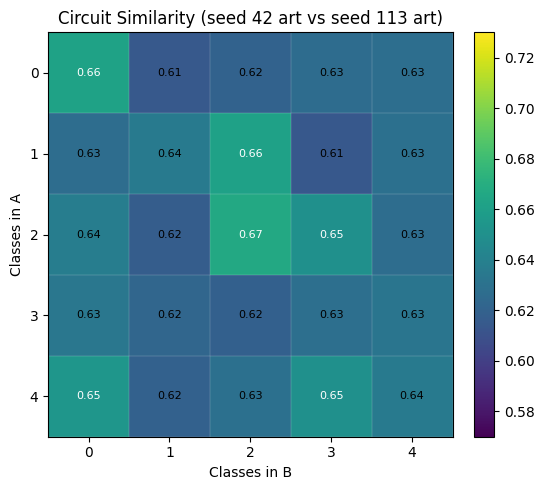

In [25]:
%matplotlib inline
vA = build_class_vectors(circuits_caltech42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_caltech113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")

In [26]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 2.9306960918019924


mean diag: 0.7390685666773106 mean offdiag: 0.6276623241905539


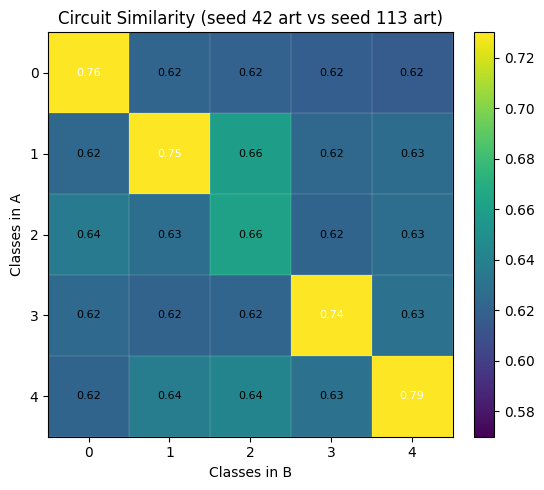

In [27]:
%matplotlib inline
vA = build_class_vectors(circuits_caltech42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_labelme42, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")

In [28]:
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

Frobenius norm: 2.868884699211163


mean diag: 0.7714395326566029 mean offdiag: 0.6287566244784303


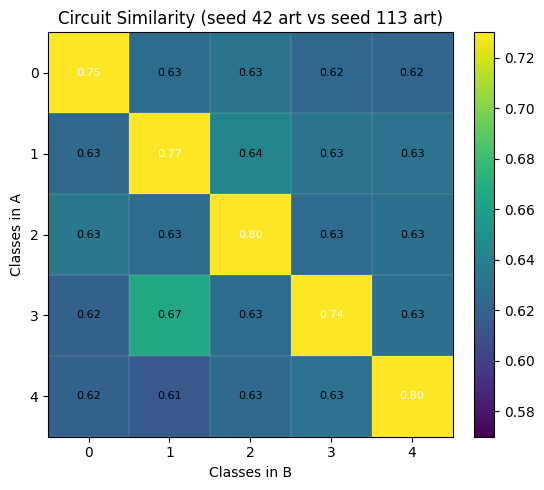

Frobenius norm: 2.85875188849261


In [29]:
%matplotlib inline
vA = build_class_vectors(circuits_caltech42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_sun42, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.8329453591806513 mean offdiag: 0.6270846262272644


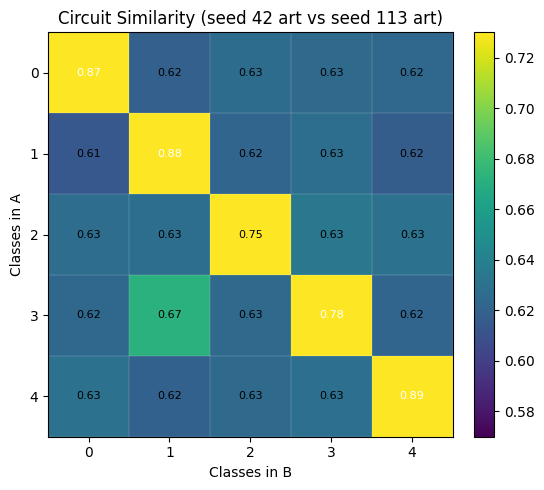

Frobenius norm: 2.832768380197509


In [30]:
%matplotlib inline
vA = build_class_vectors(circuits_caltech42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_voc42, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.8176532954437331 mean offdiag: 0.6370970701872072


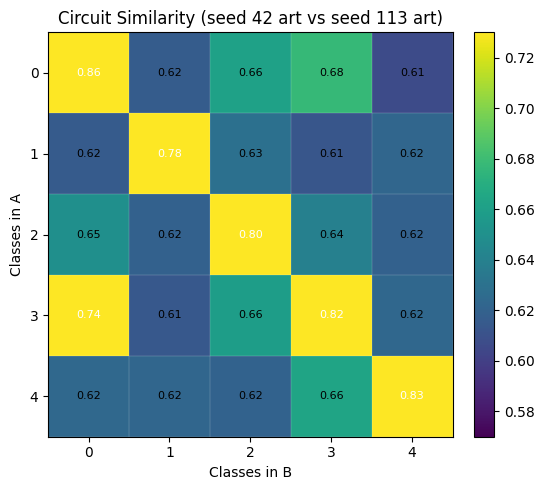

Frobenius norm: 2.8822352921323455


In [31]:
%matplotlib inline
vA = build_class_vectors(circuits_caltech113, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_labelme113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7452614517935844 mean offdiag: 0.6300441985143304


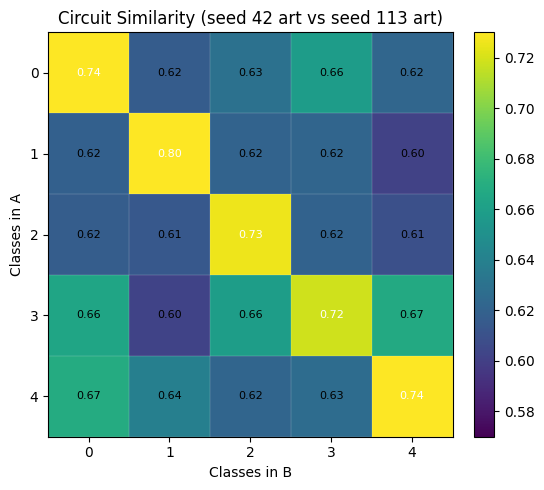

Frobenius norm: 2.876855253698162


In [32]:
%matplotlib inline
vA = build_class_vectors(circuits_caltech113, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_sun113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.8039921275995836 mean offdiag: 0.6296773137826562


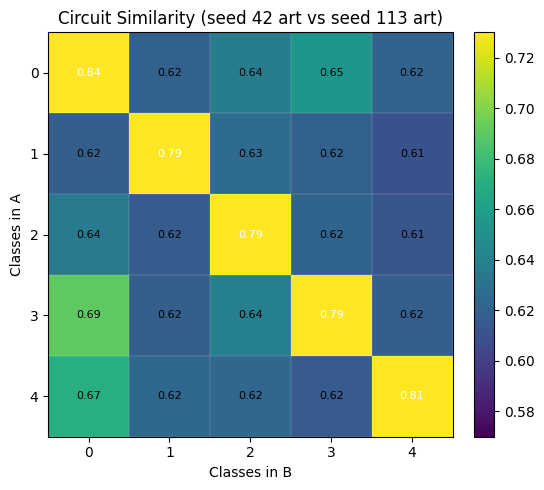

Frobenius norm: 2.8516377867427503


In [33]:
%matplotlib inline
vA = build_class_vectors(circuits_caltech113, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_voc113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.6529857053381989 mean offdiag: 0.6286682588596325


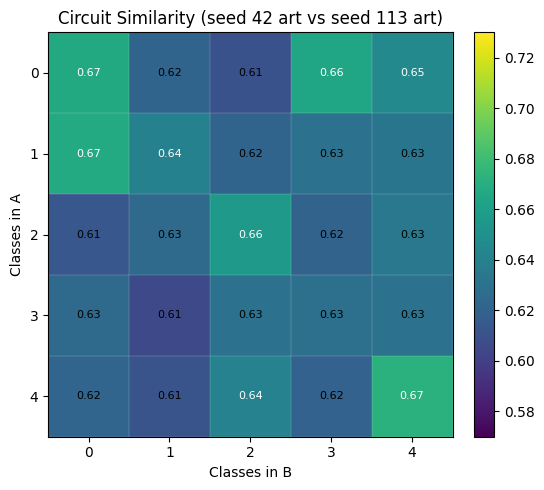

Frobenius norm: 2.9176819451702185


In [34]:
%matplotlib inline
vA = build_class_vectors(circuits_labelme42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_labelme113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7338773920235585 mean offdiag: 0.6268934178940143


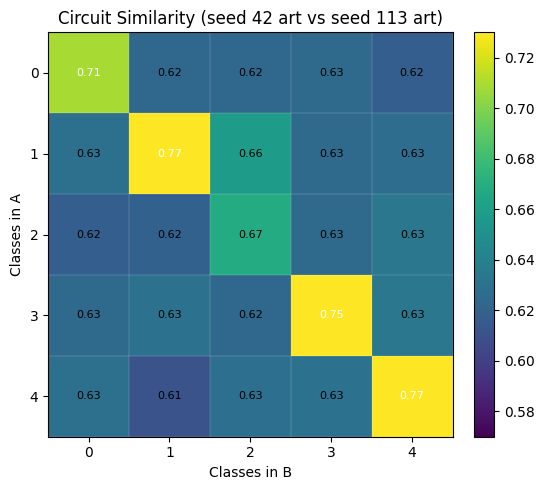

Frobenius norm: 2.8677050213391904


In [35]:
%matplotlib inline
vA = build_class_vectors(circuits_labelme42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_sun42, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7722749961539803 mean offdiag: 0.6339811960067839


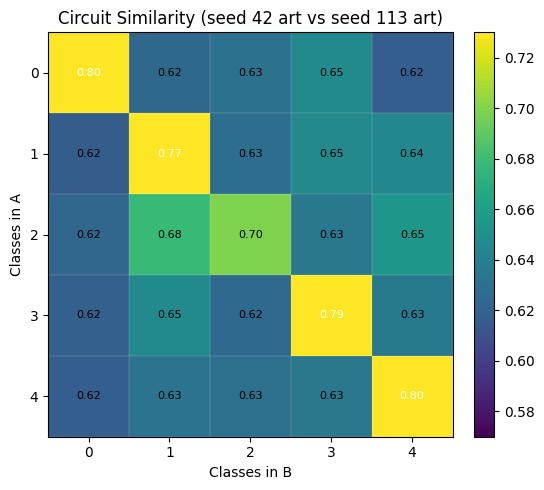

Frobenius norm: 2.882609947507453


In [36]:
%matplotlib inline
vA = build_class_vectors(circuits_labelme42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_voc42, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7398268499383768 mean offdiag: 0.6274783645989706


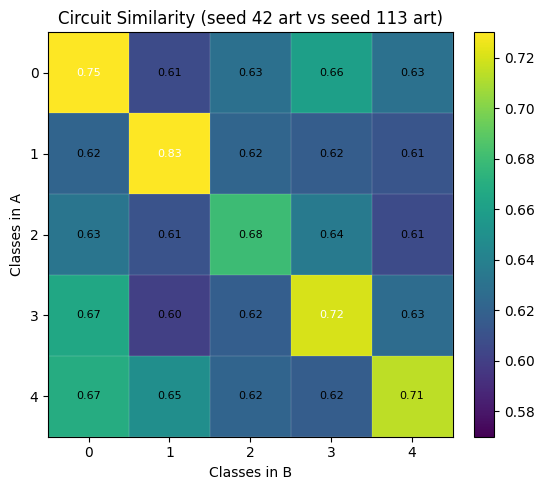

Frobenius norm: 2.869403095982257


In [37]:
%matplotlib inline
vA = build_class_vectors(circuits_labelme113, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_sun113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7947079000703592 mean offdiag: 0.6335164930893341


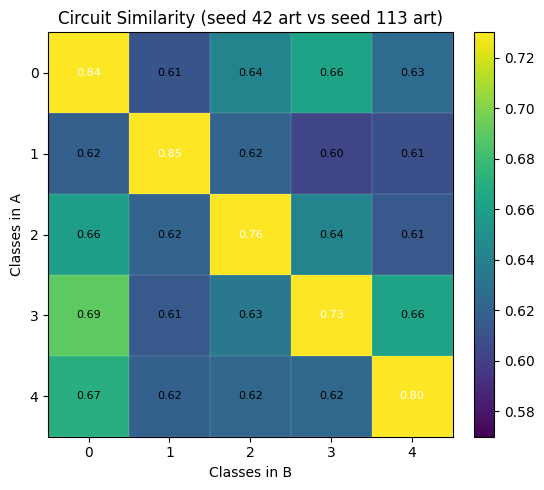

Frobenius norm: 2.8737498147361866


In [38]:
%matplotlib inline
vA = build_class_vectors(circuits_labelme113, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_voc113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.6408160541773003 mean offdiag: 0.6286381784239945


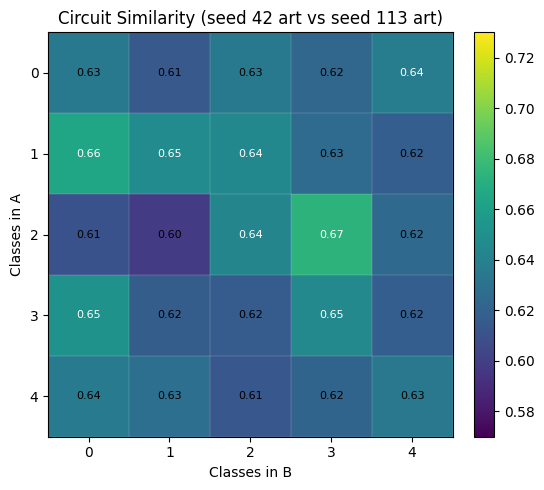

Frobenius norm: 2.9249757036295447


In [39]:
%matplotlib inline
vA = build_class_vectors(circuits_sun42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_sun113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7611117933957636 mean offdiag: 0.6255873116812396


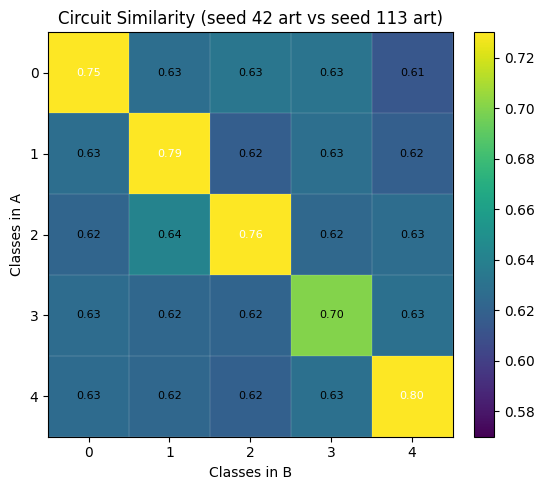

Frobenius norm: 2.849471052674607


In [40]:
%matplotlib inline
vA = build_class_vectors(circuits_sun42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_voc42, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.7597029296161264 mean offdiag: 0.6344873236045502


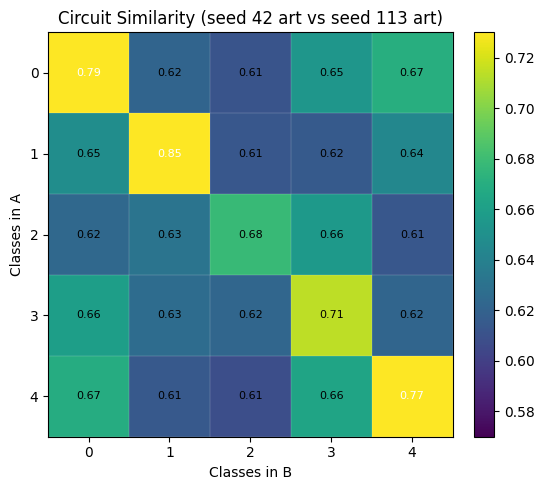

Frobenius norm: 2.8924070271053424


In [41]:
%matplotlib inline
vA = build_class_vectors(circuits_sun113, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_voc113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean diag: 0.6472542936005283 mean offdiag: 0.628687881194628


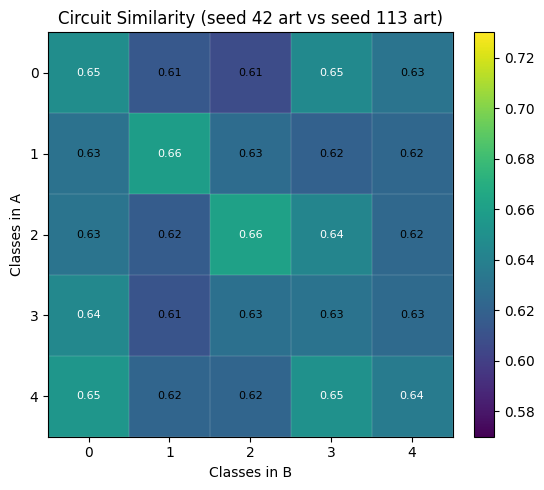

Frobenius norm: 2.920804411750284


In [42]:
%matplotlib inline
vA = build_class_vectors(circuits_voc42, use_abs_edges=True, include_bias=False)
vB = build_class_vectors(circuits_voc113, use_abs_edges=True, include_bias=False)

# 2) Compute 10x10 similarity and plot
S, classes = similarity_matrix_from_vectors(vA, vB)
print("mean diag:", np.mean(np.diag(S)), "mean offdiag:", (S.sum()-np.trace(S))/(S.size-len(S)))
plot_similarity_matrix_with_values(S, classes, title="Circuit Similarity (seed 42 art vs seed 113 art)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.960


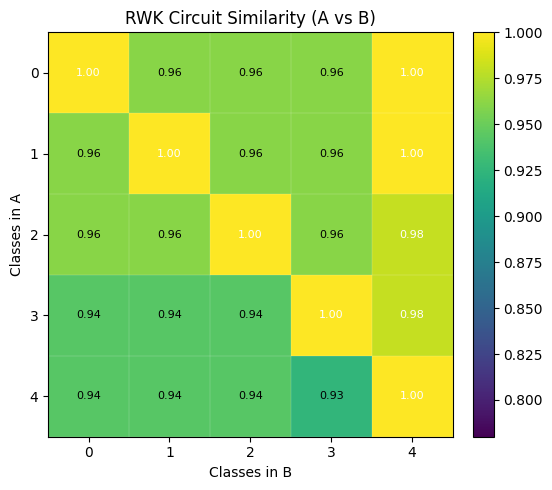

Frobenius norm: 4.2925745524448065


In [43]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_caltech42, circuits_caltech113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

In [44]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_caltech42, circuits_labelme42,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.950
Frobenius norm: 4.25112593877188


mean(diagonal)=1.000, mean(off-diagonal)=0.926


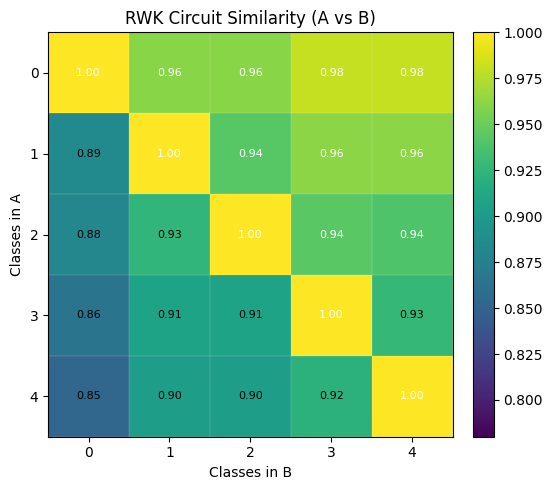

Frobenius norm: 4.142522587209816


In [45]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_caltech42, circuits_sun42,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

In [46]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_caltech42, circuits_voc42,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.976
Frobenius norm: 4.363452467654271


In [47]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_caltech113, circuits_labelme113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.959
Frobenius norm: 4.289655492235678


In [48]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_caltech113, circuits_sun113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.910
Frobenius norm: 4.075220226107872


In [49]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_caltech113, circuits_voc113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.961
Frobenius norm: 4.298518814322674


In [50]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_labelme42, circuits_labelme113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.951
Frobenius norm: 4.255710231343118


In [51]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_labelme42, circuits_sun42,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.927
Frobenius norm: 4.146985168846037


In [52]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_labelme42, circuits_voc42,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.964
Frobenius norm: 4.311551309906702


In [53]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_labelme113, circuits_sun113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.918
Frobenius norm: 4.110879440816348


In [54]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_labelme113, circuits_voc113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.963
Frobenius norm: 4.305921290595279


In [55]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_sun42, circuits_sun113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.904
Frobenius norm: 4.044142735193733


In [56]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_sun42, circuits_voc42,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.941
Frobenius norm: 4.2111681010675905


In [57]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_sun113, circuits_voc113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.922
Frobenius norm: 4.1263496767819


In [58]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S,classes = rwk_similarity_matrix(
    circuits_voc42, circuits_voc113,
    lam=1e-2,                 # try 1e-3 .. 1e-1 if you want stronger/weaker smoothing
    compute_method='conjugate',  # 'conjugate' or 'fp' avoid the control toolbox
    use_abs_edges=True
)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_similarity_matrix_with_values_rwk(S, classes, title="RWK Circuit Similarity (A vs B)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

mean(diagonal)=1.000, mean(off-diagonal)=0.971
Frobenius norm: 4.342357141837074


In [59]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_caltech42, circuits_caltech113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 558.01it/s]
getting canonkeys: 3it [00:00, 4121.49it/s]

 --- treelet kernel matrix of size 2 built in 0.011224985122680664 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 439.19it/s]
getting canonkeys: 3it [00:00, 12052.60it/s]

 --- treelet kernel matrix of size 2 built in 0.011686086654663086 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 433.90it/s]
getting canonkeys: 3it [00:00, 13052.81it/s]

 --- treelet kernel matrix of size 2 built in 0.011583328247070312 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 447.75it/s]
getting canonkeys: 3it [00:00, 12532.78it/s]

 --- treelet kernel matrix of size 2 built in 0.011398077011108398 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 447.89it/s]
getting canonkeys: 3it [00:00, 12985.46it/s]

 --- treelet kernel matrix of size 2 built in 0.011420726776123047 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

In [60]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_caltech42, circuits_labelme42, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 423.37it/s]
getting canonkeys: 3it [00:00, 11315.57it/s]

 --- treelet kernel matrix of size 2 built in 0.012622833251953125 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 436.66it/s]
getting canonkeys: 3it [00:00, 10609.54it/s]

 --- treelet kernel matrix of size 2 built in 0.012618780136108398 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 448.32it/s]
getting canonkeys: 3it [00:00, 10330.80it/s]

 --- treelet kernel matrix of size 2 built in 0.012295246124267578 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 442.55it/s]
getting canonkeys: 3it [00:00, 11837.17it/s]

 --- treelet kernel matrix of size 2 built in 0.012003660202026367 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 393.94it/s]
getting canonkeys: 3it [00:00, 11586.48it/s]

 --- treelet kernel matrix of size 2 built in 0.01309347152709961 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

In [61]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_caltech42, circuits_sun42, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 437.48it/s]
getting canonkeys: 3it [00:00, 11214.72it/s]

 --- treelet kernel matrix of size 2 built in 0.012077093124389648 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.01it/s]
getting canonkeys: 3it [00:00, 11618.57it/s]

 --- treelet kernel matrix of size 2 built in 0.012196779251098633 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 435.34it/s]
getting canonkeys: 3it [00:00, 10547.29it/s]

 --- treelet kernel matrix of size 2 built in 0.013014554977416992 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.14it/s]
getting canonkeys: 3it [00:00, 11859.48it/s]



 --- treelet kernel matrix of size 2 built in 0.011888504028320312 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 399.82it/s]
getting canonkeys: 3it [00:00, 12006.60it/s]

 --- treelet kernel matrix of size 2 built in 0.012590408325195312 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.15it/s]
getting canonkeys: 3it [00:00, 13012.32it/s]

 --- treelet kernel matrix of size 2 built in 0.01110529899597168 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 467.70it/s]
getting canonkeys: 3it [00:00, 13371.85it/s]

 --- treelet kernel matrix of size 2 built in 0.01124715805053711 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 441.55it/s]
getting canonkeys: 3it [00:00, 13400.33it/s]

 --- treelet kernel matrix of size 2 built in 0.011713981628417969 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.64it/s]
getting canonkeys: 3it [00:00, 12945.38it/s]

 --- treelet kernel matrix of size 2 built in

In [62]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_caltech42, circuits_voc42, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.50it/s]
getting canonkeys: 3it [00:00, 11737.79it/s]

 --- treelet kernel matrix of size 2 built in 0.01228475570678711 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 309.75it/s]
getting canonkeys: 3it [00:00, 11629.31it/s]

 --- treelet kernel matrix of size 2 built in 0.014471769332885742 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 439.01it/s]
getting canonkeys: 3it [00:00, 11174.88it/s]

 --- treelet kernel matrix of size 2 built in 0.012636899948120117 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 447.99it/s]
getting canonkeys: 3it [00:00, 11672.46it/s]

 --- treelet kernel matrix of size 2 built in 0.012264490127563477 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 373.41it/s]
getting canonkeys: 3it [00:00, 10745.44it/s]

 --- treelet kernel matrix of size 2 built in 0.012808561325073242 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00


getting canonkeys: 3it [00:00, 11618.57it/s]

 --- treelet kernel matrix of size 2 built in 0.012449026107788086 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 398.83it/s]
getting canonkeys: 3it [00:00, 11194.76it/s]

 --- treelet kernel matrix of size 2 built in 0.012321710586547852 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.53it/s]
getting canonkeys: 3it [00:00, 12216.42it/s]

 --- treelet kernel matrix of size 2 built in 0.01268315315246582 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 326.40it/s]
getting canonkeys: 3it [00:00, 11848.32it/s]

 --- treelet kernel matrix of size 2 built in 0.01363825798034668 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.56it/s]
getting canonkeys: 3it [00:00, 11983.73it/s]

 --- treelet kernel matrix of size 2 built in 0.012237310409545898 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 447.42it/s]
getting canonkeys: 3it [00:00, 11870.67it/s]



In [63]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_caltech113, circuits_labelme113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.62it/s]
getting canonkeys: 3it [00:00, 11597.15it/s]

 --- treelet kernel matrix of size 2 built in 0.012376546859741211 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.32it/s]
getting canonkeys: 3it [00:00, 12041.06it/s]

 --- treelet kernel matrix of size 2 built in 0.012413263320922852 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 465.00it/s]
getting canonkeys: 3it [00:00, 11938.25it/s]

 --- treelet kernel matrix of size 2 built in 0.01174306869506836 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 461.12it/s]
getting canonkeys: 3it [00:00, 11459.85it/s]

 --- treelet kernel matrix of size 2 built in 0.011916875839233398 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 452.07it/s]
getting canonkeys: 3it [00:00, 10837.99it/s]

 --- treelet kernel matrix of size 2 built in 0.012384414672851562 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

In [64]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_caltech113, circuits_sun113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 448.66it/s]
getting canonkeys: 3it [00:00, 11356.42it/s]

 --- treelet kernel matrix of size 2 built in 0.012557029724121094 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.92it/s]
getting canonkeys: 3it [00:00, 11803.86it/s]

 --- treelet kernel matrix of size 2 built in 0.012237787246704102 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.65it/s]
getting canonkeys: 3it [00:00, 11254.84it/s]

 --- treelet kernel matrix of size 2 built in 0.012394189834594727 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.87it/s]
getting canonkeys: 3it [00:00, 11826.05it/s]

 --- treelet kernel matrix of size 2 built in 0.011984825134277344 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 399.97it/s]
getting canonkeys: 3it [00:00, 11533.37it/s]

 --- treelet kernel matrix of size 2 built in 0.01277470588684082 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

In [65]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_caltech113, circuits_voc113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 432.63it/s]
getting canonkeys: 3it [00:00, 11770.73it/s]

 --- treelet kernel matrix of size 2 built in 0.012380123138427734 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 465.88it/s]
getting canonkeys: 3it [00:00, 11376.95it/s]

 --- treelet kernel matrix of size 2 built in 0.012002944946289062 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 467.46it/s]
getting canonkeys: 3it [00:00, 12288.00it/s]

 --- treelet kernel matrix of size 2 built in 0.011701345443725586 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 454.49it/s]
getting canonkeys: 3it [00:00, 12052.60it/s]

 --- treelet kernel matrix of size 2 built in 0.011933088302612305 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 460.99it/s]
getting canonkeys: 3it [00:00, 11870.67it/s]

 --- treelet kernel matrix of size 2 built in 0.011690139770507812 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

In [66]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_labelme42, circuits_labelme113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.04it/s]
getting canonkeys: 3it [00:00, 11575.82it/s]

 --- treelet kernel matrix of size 2 built in 0.012153863906860352 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 447.23it/s]
getting canonkeys: 3it [00:00, 11949.58it/s]

 --- treelet kernel matrix of size 2 built in 0.012048006057739258 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.69it/s]
getting canonkeys: 3it [00:00, 11737.79it/s]

 --- treelet kernel matrix of size 2 built in 0.011850595474243164 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 453.41it/s]
getting canonkeys: 3it [00:00, 11915.64it/s]

 --- treelet kernel matrix of size 2 built in 0.012218713760375977 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.35it/s]
getting canonkeys: 3it [00:00, 11661.64it/s]

 --- treelet kernel matrix of size 2 built in 0.011877298355102539 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.38it/s]
getting canonkeys: 3it [00:00, 11726.85it/s]

 --- treelet kernel matrix of size 2 built in 0.011324405670166016 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 451.17it/s]
getting canonkeys: 3it [00:00, 11781.75it/s]

 --- treelet kernel matrix of size 2 built in 0.012359380722045898 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 444.90it/s]
getting canonkeys: 3it [00:00, 10989.44it/s]

 --- treelet kernel matrix of size 2 built in 0.012102603912353516 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.25it/s]
getting canonkeys: 3it [00:00, 11650.84it/s]

 --- treelet kernel matrix of size 2 built in 0.011908531188964844 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.24it/s]
getting canonkeys: 3it [00:00, 11759.73it/s]

 --- treelet kernel matrix of size 2 built in 0.011893033981323242 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

In [67]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_labelme42, circuits_sun42, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.30it/s]
getting canonkeys: 3it [00:00, 11428.62it/s]

 --- treelet kernel matrix of size 2 built in 0.012483596801757812 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 406.23it/s]
getting canonkeys: 3it [00:00, 11848.32it/s]

 --- treelet kernel matrix of size 2 built in 0.012347221374511719 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 442.27it/s]
getting canonkeys: 3it [00:00, 11748.75it/s]

 --- treelet kernel matrix of size 2 built in 0.012208223342895508 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 453.49it/s]
getting canonkeys: 3it [00:00, 11554.56it/s]

 --- treelet kernel matrix of size 2 built in 0.012055635452270508 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.17it/s]
getting canonkeys: 3it [00:00, 11629.31it/s]

 --- treelet kernel matrix of size 2 built in 0.01192927360534668 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

In [68]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_labelme42, circuits_voc42, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 481.14it/s]
getting canonkeys: 3it [00:00, 11661.64it/s]

 --- treelet kernel matrix of size 2 built in 0.011320829391479492 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.61it/s]
getting canonkeys: 3it [00:00, 11224.72it/s]

 --- treelet kernel matrix of size 2 built in 0.012198686599731445 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 427.36it/s]
getting canonkeys: 3it [00:00, 11295.25it/s]

 --- treelet kernel matrix of size 2 built in 0.012628793716430664 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 445.49it/s]
getting canonkeys: 3it [00:00, 11715.93it/s]

 --- treelet kernel matrix of size 2 built in 0.012122154235839844 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.30it/s]
getting canonkeys: 3it [00:00, 12041.06it/s]

 --- treelet kernel matrix of size 2 built in 0.012285232543945312 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

In [69]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_labelme113, circuits_sun113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.62it/s]
getting canonkeys: 3it [00:00, 11826.05it/s]

 --- treelet kernel matrix of size 2 built in 0.012310504913330078 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.60it/s]
getting canonkeys: 3it [00:00, 11770.73it/s]

 --- treelet kernel matrix of size 2 built in 0.011709213256835938 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 328.63it/s]
getting canonkeys: 3it [00:00, 11407.90it/s]

 --- treelet kernel matrix of size 2 built in 0.013943672180175781 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 462.92it/s]
getting canonkeys: 3it [00:00, 11949.58it/s]

 --- treelet kernel matrix of size 2 built in 0.011586666107177734 seconds ---
getting canonkeys:   0%|          | 0/2 [00:00<?, ?it/s]

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 469.16it/s]
getting canonkeys: 3it [00:00, 11428.62it/s]

 --- treelet kernel matrix of size 2 built in 0.012031078338623047 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 371.37it/s]
getting canonkeys: 3it [00:00, 11366.68it/s]

 --- treelet kernel matrix of size 2 built in 0.012607574462890625 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.43it/s]
getting canonkeys: 3it [00:00, 11960.94it/s]

 --- treelet kernel matrix of size 2 built in 0.012278318405151367 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 456.62it/s]
getting canonkeys: 3it [00:00, 11881.88it/s]

 --- treelet kernel matrix of size 2 built in 0.012391090393066406 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 444.36it/s]
getting canonkeys: 3it [00:00, 11848.32it/s]

 --- treelet kernel matrix of size 2 built in 0.012388229370117188 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

In [70]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_labelme113, circuits_voc113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 447.87it/s]
getting canonkeys: 3it [00:00, 11512.27it/s]

 --- treelet kernel matrix of size 2 built in 0.012202739715576172 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.36it/s]
getting canonkeys: 3it [00:00, 11759.73it/s]

 --- treelet kernel matrix of size 2 built in 0.012314558029174805 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 468.30it/s]
getting canonkeys: 3it [00:00, 12098.95it/s]

 --- treelet kernel matrix of size 2 built in 0.011751413345336914 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.15it/s]
getting canonkeys: 3it [00:00, 11904.36it/s]

 --- treelet kernel matrix of size 2 built in 0.012189388275146484 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 442.51it/s]
getting canonkeys: 3it [00:00, 11575.82it/s]

 --- treelet kernel matrix of size 2 built in 0.012334346771240234 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

In [71]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_sun42, circuits_sun113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 444.45it/s]
getting canonkeys: 3it [00:00, 11748.75it/s]

 --- treelet kernel matrix of size 2 built in 0.012148380279541016 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.91it/s]
getting canonkeys: 3it [00:00, 11972.32it/s]

 --- treelet kernel matrix of size 2 built in 0.01208353042602539 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 455.43it/s]
getting canonkeys: 3it [00:00, 12075.73it/s]

 --- treelet kernel matrix of size 2 built in 0.012003183364868164 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 410.88it/s]
getting canonkeys: 3it [00:00, 10600.60it/s]

 --- treelet kernel matrix of size 2 built in 0.012551069259643555 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 463.08it/s]
getting canonkeys: 3it [00:00, 11972.32it/s]

 --- treelet kernel matrix of size 2 built in 0.011796712875366211 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00

In [72]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_sun42, circuits_voc42, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 454.74it/s]
getting canonkeys: 3it [00:00, 11781.75it/s]

 --- treelet kernel matrix of size 2 built in 0.011986255645751953 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 450.01it/s]
getting canonkeys: 3it [00:00, 12169.16it/s]

 --- treelet kernel matrix of size 2 built in 0.011909008026123047 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 442.81it/s]
getting canonkeys: 3it [00:00, 10699.76it/s]

 --- treelet kernel matrix of size 2 built in 0.012994527816772461 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.24it/s]
getting canonkeys: 3it [00:00, 10932.16it/s]

 --- treelet kernel matrix of size 2 built in 0.012204647064208984 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 444.31it/s]
getting canonkeys: 3it [00:00, 12041.06it/s]

 --- treelet kernel matrix of size 2 built in 0.012290239334106445 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

In [73]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_sun113, circuits_voc113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 412.83it/s]
getting canonkeys: 3it [00:00, 11174.88it/s]

 --- treelet kernel matrix of size 2 built in 0.013184070587158203 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.82it/s]
getting canonkeys: 3it [00:00, 11926.93it/s]

 --- treelet kernel matrix of size 2 built in 0.012105226516723633 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 459.10it/s]
getting canonkeys: 3it [00:00, 12110.60it/s]

 --- treelet kernel matrix of size 2 built in 0.011883735656738281 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 396.10it/s]
getting canonkeys: 3it [00:00, 10979.85it/s]

 --- treelet kernel matrix of size 2 built in 0.012614965438842773 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 438.00it/s]
getting canonkeys: 3it [00:00, 11904.36it/s]

 --- treelet kernel matrix of size 2 built in 0.012472391128540039 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.52it/s]
getting canonkeys: 3it [00:00, 12157.40it/s]

 --- treelet kernel matrix of size 2 built in 0.01204824447631836 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 437.59it/s]
getting canonkeys: 3it [00:00, 11972.32it/s]

 --- treelet kernel matrix of size 2 built in 0.01261448860168457 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 457.07it/s]
getting canonkeys: 3it [00:00, 11960.94it/s]

 --- treelet kernel matrix of size 2 built in 0.011818647384643555 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 451.63it/s]
getting canonkeys: 3it [00:00, 11983.73it/s]

 --- treelet kernel matrix of size 2 built in 0.011970996856689453 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 463.13it/s]
getting canonkeys: 3it [00:00, 12075.73it/s]

 --- treelet kernel matrix of size 2 built in 0.01179957389831543 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<0

In [74]:
# circuits_A, circuits_B = ...  # your two dicts: {0..9 -> circuit_record}
S, classes = treelet_similarity_matrix(circuits_voc42, circuits_voc113, sub_kernel=highest_polynomial_kernel)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")
%matplotlib inline
#plot_treelet_similarity_matrix_with_values(S, classes, title="Treelet Circuit Similarity (seed 42 MNIST vs seed 113 MNIST)", fmt=".2f")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)

getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 446.39it/s]
getting canonkeys: 3it [00:00, 11726.85it/s]

 --- treelet kernel matrix of size 2 built in 0.011894941329956055 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 464.97it/s]
getting canonkeys: 3it [00:00, 11893.11it/s]

 --- treelet kernel matrix of size 2 built in 0.012041091918945312 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 449.00it/s]
getting canonkeys: 3it [00:00, 11837.17it/s]

 --- treelet kernel matrix of size 2 built in 0.012003898620605469 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 469.79it/s]
getting canonkeys: 3it [00:00, 12006.60it/s]

 --- treelet kernel matrix of size 2 built in 0.011632204055786133 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:00<00:00, 458.32it/s]
getting canonkeys: 3it [00:00, 11759.73it/s]

 --- treelet kernel matrix of size 2 built in 0.011792898178100586 seconds ---
getting canonkeys: 100%|██████████| 2/2 [00:0